# Model Development

This notebook documents feature engineering, model selection, and hyperparameter tuning for heart disease risk prediction. It calls straight
into the tested project modules (`heart_disease.features`, `heart_disease.train`) rather than re-implementing the logic, so what you see here is exactly what the CI pipeline and the served model run.

See `notebooks/eda.ipynb` for the exploratory analysis that motivated these choices.

In [1]:
import pandas as pd
from IPython.display import Image, display
from sklearn.model_selection import train_test_split

from heart_disease.data import TARGET, get_clean_dataset
from heart_disease.features import build_pipeline, build_preprocessor
from heart_disease import train as train_module

pd.set_option("display.max_columns", 20)

/Users/vijendra/myMTech/Sem3/MLOpsS2-25_AIMLCZG523/assignment1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the cleaned dataset and split

In [2]:
df = get_clean_dataset()
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=train_module.RANDOM_STATE
)
print(f"train: {X_train.shape}, test: {X_test.shape}")
y_train.value_counts(normalize=True)

train: (242, 13), test: (61, 13)


target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

## 2. Feature engineering pipeline

`build_preprocessor()` (`src/heart_disease/features.py`) applies:
- `StandardScaler` to the 5 numeric features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`)
- `OneHotEncoder(handle_unknown="ignore", drop="if_binary")` to the 8 categorical features
  (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`)

Wrapping this in one `sklearn.Pipeline` alongside the classifier guarantees training and
inference apply identical transformations there is no separate preprocessing script to
drift out of sync with the API.

In [3]:
preprocessor = build_preprocessor()
transformed = preprocessor.fit_transform(X_train)
print("encoded feature matrix shape:", transformed.shape)
print("output feature names:", list(preprocessor.get_feature_names_out()))

encoded feature matrix shape: (242, 25)
output feature names: ['numeric__age', 'numeric__trestbps', 'numeric__chol', 'numeric__thalach', 'numeric__oldpeak', 'categorical__sex_1', 'categorical__cp_1', 'categorical__cp_2', 'categorical__cp_3', 'categorical__cp_4', 'categorical__fbs_1', 'categorical__restecg_0', 'categorical__restecg_1', 'categorical__restecg_2', 'categorical__exang_1', 'categorical__slope_1', 'categorical__slope_2', 'categorical__slope_3', 'categorical__ca_0', 'categorical__ca_1', 'categorical__ca_2', 'categorical__ca_3', 'categorical__thal_3', 'categorical__thal_6', 'categorical__thal_7']


## 3. Model selection & hyperparameter search space

Two classifiers are compared, each tuned with `GridSearchCV` (5-fold `StratifiedKFold`,
scored on ROC-AUC) — the search space is defined once in `heart_disease.train` and reused
here so the notebook and the training script can never disagree:

In [4]:
for name, spec in train_module.MODEL_SEARCH_SPACE.items():
    print(name, "->", spec["param_grid"])

logistic_regression -> {'classifier__C': [0.01, 0.1, 1, 10], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}
random_forest -> {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5, None], 'classifier__min_samples_leaf': [1, 2, 4]}


## 4. Train, tune, and track both models

`train_and_track` fits each model's pipeline with `GridSearchCV`, re-validates the best
estimator with cross-validation, evaluates it on the held-out test set, logs everything
(params, metrics, confusion matrix, ROC curve, model artifact) to MLflow, and persists the
pipelines under `models/`. Re-running this cell reproduces the full experiment from scratch.

In [5]:
run_result = train_module.train_and_track(df)
print("best model:", run_result["best_model_name"])

2026/07/07 13:40:33 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-risk' does not exist. Creating a new experiment.


Training models:   0%|                                                                                                                                            | 0/2 [00:00<?, ?model/s]

Training logistic_regression:   0%|                                                                                                                               | 0/2 [00:00<?, ?model/s]

  Tuning logistic_regression:   0%|                                                                                                                                | 0/20 [00:00<?, ?fit/s]

  Tuning logistic_regression:  45%|██████████████████████████████████████████████████████                                                                  | 9/20 [00:00<00:00, 76.57fit/s]

...

INFO:heart_disease.train:random_forest: test metrics={'accuracy': 0.8688524590163934, 'precision': np.float64(0.8125), 'recall': np.float64(0.9285714285714286), 'f1': np.float64(0.8666666666666667), 'roc_auc': np.float64(0.9545454545454546)} cv_roc_auc=0.9027


Training random_forest: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:18<00:00, 10.34s/model]

Training random_forest: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:18<00:00,  9.48s/model]


INFO:heart_disease.train:Best model: logistic_regression (test ROC-AUC=0.9675)


best model: logistic_regression


## 5. Model comparison

In [6]:
comparison = pd.DataFrame(
    {
        name: {**res["metrics"], "cv_roc_auc_mean": res["cv_roc_auc_mean"]}
        for name, res in run_result["results"].items()
    }
).T
comparison.sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean
logistic_regression,0.885246,0.83871,0.928571,0.881356,0.967532,0.903516
random_forest,0.868852,0.81250,0.928571,0.866667,0.954545,0.902666


## 6. Confusion matrices & ROC curves

Saved to `reports/figures/` by the training run above.

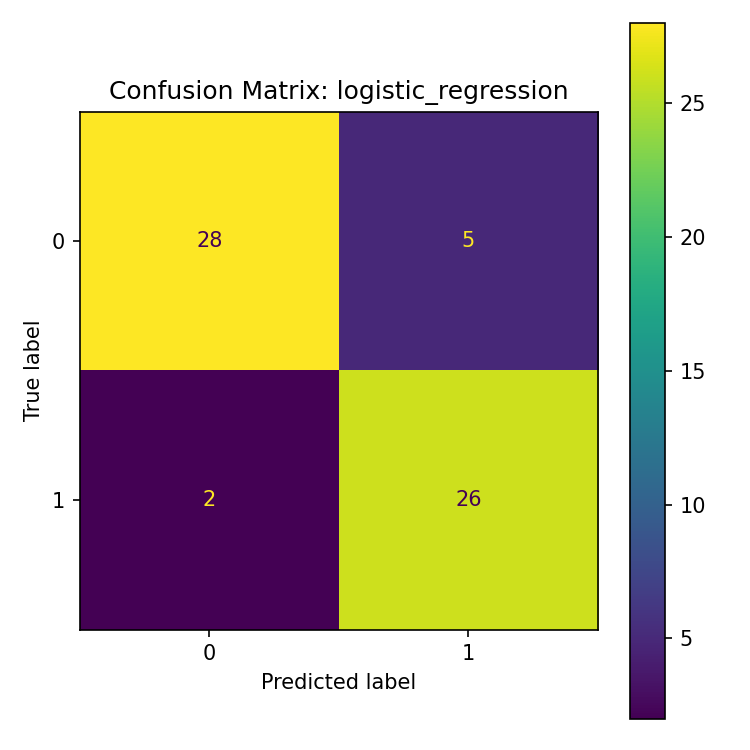

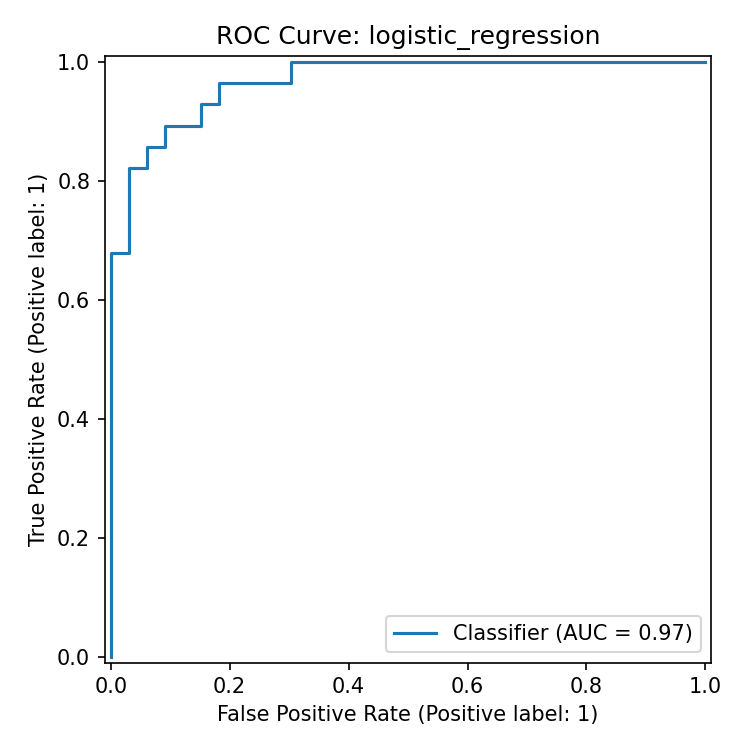

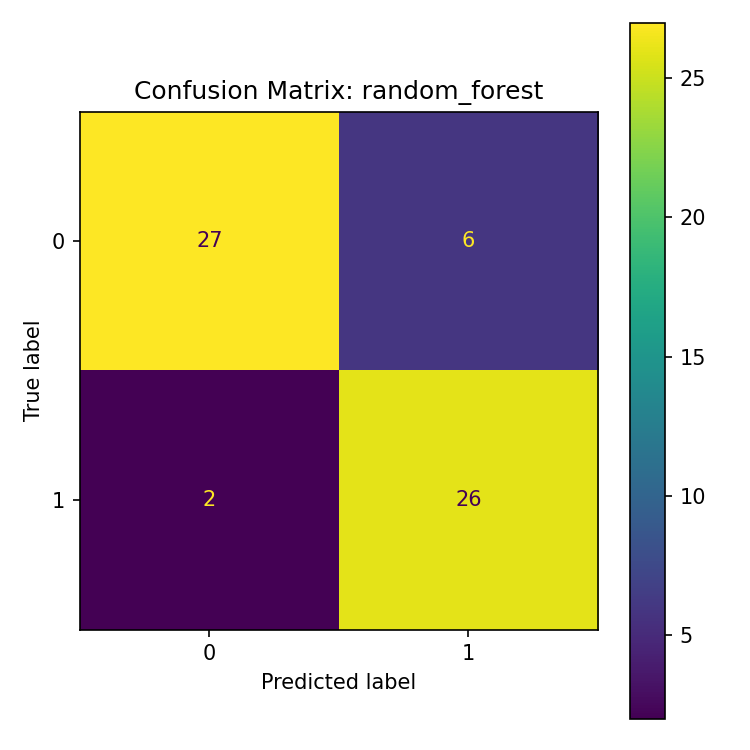

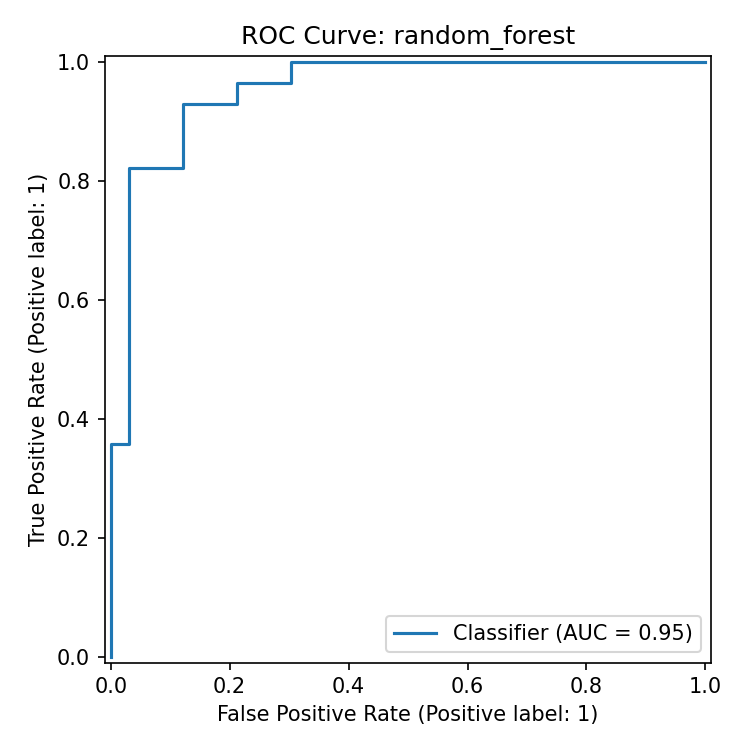

In [7]:
for name in run_result["results"]:
    display(Image(filename=f"../reports/figures/confusion_matrix_{name}.png"))
    display(Image(filename=f"../reports/figures/roc_curve_{name}.png"))

## 7. Reproducibility check

Load the persisted best pipeline exactly the way the API does (`heart_disease.predict.
HeartDiseaseModel`) and confirm it reproduces a prediction on a held-out test row.

In [8]:
from heart_disease.predict import FEATURE_ORDER, HeartDiseaseModel

model = HeartDiseaseModel()  # loads models/best_model.joblib
sample = {col: X_test.iloc[0][col] for col in FEATURE_ORDER}
print("input:", sample)
print("prediction:", model.predict_one(sample))
print("actual label:", int(y_test.iloc[0]))

input: {'age': np.float64(59.0), 'trestbps': np.float64(138.0), 'chol': np.float64(271.0), 'thalach': np.float64(182.0), 'oldpeak': np.float64(0.0), 'sex': np.float64(1.0), 'cp': np.float64(4.0), 'fbs': np.float64(0.0), 'restecg': np.float64(2.0), 'exang': np.float64(0.0), 'slope': np.float64(1.0), 'ca': np.float64(0.0), 'thal': np.float64(3.0)}
prediction: {'prediction': 0, 'probability': 0.20207142175245088}
actual label: 0


## 8. Summary

- Logistic Regression and Random Forest were both tuned with `GridSearchCV` on ROC-AUC.
- Logistic Regression was selected as the best model on the held-out test set (highest
  ROC-AUC, consistent with cross-validation), and is what `models/best_model.joblib` and the
  FastAPI service (`api/main.py`) serve.
- Every run's parameters, metrics, and artifacts are tracked in MLflow — see
  `mlflow ui --backend-store-uri ../mlruns` (or `./mlruns` from the repo root).